<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 1 — Introducción con PhysioNet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->
<font color="#7F000E" size=3> Nivel: Ingeniería Biomédica — 7.º ciclo / 4.º año </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Importación, exploración, visualización y exportación de ECG </font><br>
</div>

---

## Objetivos

Al finalizar este laboratorio, el estudiante será capaz de:

1. Acceder a una base de datos de señales fisiológicas de PhysioNet.
2. Cargar un registro ECG mediante la librería `wfdb`.
3. Identificar la frecuencia de muestreo, número de canales, nombres de canales y duración.
4. Construir el eje temporal de una señal discreta.
5. Visualizar una señal ECG mediante diferentes representaciones.
6. Analizar un segmento de la señal.
7. Exportar un segmento ECG a formato `.wav`.
8. Interpretar las diferencias entre una señal biomédica y una señal de audio.
9. Formular observaciones básicas sobre la morfología y amplitud de un ECG.

> **Importante:** el archivo WAV generado es una representación de la señal ECG en un formato reproducible por herramientas de audio. No significa que el ECG sea originalmente una señal acústica.



## 1. Introducción

Las señales biomédicas son señales generadas por procesos fisiológicos. Algunos ejemplos son:

- ECG — electrocardiograma
- EEG — electroencefalograma
- EMG — electromiograma
- EOG — electrooculograma
- PPG — fotopletismografía

En este laboratorio trabajaremos con una señal **ECG real** obtenida de **PhysioNet**.

PhysioNet proporciona acceso a numerosas bases de datos fisiológicas. Una de las bases más conocidas es la **MIT-BIH Arrhythmia Database**, que contiene registros electrocardiográficos anotados.

### Concepto fundamental: DATABASE + RECORD

Un registro no debe identificarse solamente por su número.

Por ejemplo:

```python
DATABASE = "mitdb"
RECORD = "100"
```

significa que estamos solicitando el registro `100` de la base de datos `mitdb`.

El mismo número de registro puede tener un significado diferente si pertenece a otra base de datos. Por ello, siempre debemos interpretar:

```text
BASE DE DATOS + RECORD
```

como la identificación del registro.



## 2. Parámetros configurables

En esta sección el estudiante podrá cambiar los parámetros principales del laboratorio.

### Parámetros

| Parámetro | Descripción | Ejemplo |
|---|---|---|
| `DATABASE` | Base de datos de PhysioNet | `"mitdb"` |
| `RECORD` | Identificador del registro | `"100"` |
| `CHANNEL` | Canal que se desea analizar | `0` |
| `DURATION` | Duración del segmento en segundos | `10` |
| `OUTPUT_WAV` | Nombre del archivo WAV | `"ecg_100.wav"` |

### Pregunta inicial

Antes de ejecutar el código, responda:

**¿Qué cree que representa `CHANNEL = 0`?**

Representa el subarreglo de la señal que vamos a analizar, en este caso el 0 (el primero)

Anote su hipótesis y compruébela después de ejecutar el notebook.


In [ ]:

# ============================================
# PARÁMETROS DEL LABORATORIO
# ============================================

DATABASE = "mitdb"
RECORD = "100"

CHANNEL = 0

DURATION = 10  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")


Parámetros configurados:
Base de datos : mitdb
Registro      : 100
Canal         : 0
Duración      : 10 s
Archivo WAV   : ecg_record_100_channel_0.wav



## 3. Instalación de librerías

Utilizaremos:

- **WFDB:** acceso a registros de PhysioNet.
- **NumPy:** procesamiento numérico.
- **Pandas:** organización de datos.
- **Matplotlib:** visualización.
- **SciPy:** exportación de la señal a WAV.


In [ ]:
!pip install uv

In [ ]:

# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!uv pip install -q wfdb scipy pandas numpy matplotlib


In [ ]:

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from IPython.display import Audio, display

print("Librerías importadas correctamente.")


Librerías importadas correctamente.



## 4. Cargar el registro desde PhysioNet

La función principal será:

```python
wfdb.rdrecord()
```

Usaremos:

```python
record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)
```

El argumento `pn_dir` indica que el registro se obtendrá desde una base de datos disponible en PhysioNet.


In [ ]:

# ============================================
# CARGAR REGISTRO DESDE PHYSIONET
# ============================================

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")


Registro cargado correctamente.



## 5. Explorar la información del registro

Antes de procesar una señal biomédica es necesario conocer sus características.

Algunos parámetros importantes son:

- `fs`: frecuencia de muestreo.
- `sig_len`: número de muestras.
- `n_sig`: número de canales.
- `sig_name`: nombres de los canales.
- `units`: unidades de las señales.


In [ ]:

# ============================================
# INFORMACIÓN DEL REGISTRO
# ============================================

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)


INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 100
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V5']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos



### Preguntas de análisis 1

1. ¿Cuál es la frecuencia de muestreo del registro?

    - La frecuencia de muestreo del registro es 360 Hz.

2. ¿Cuántos canales tiene?

    - Tiene 2 canales, 'MLII' y 'V5'.

3. ¿Cómo se llama el canal seleccionado?

    - El canal seleccionado se llama 'MLII'.

4. ¿Cuál es la duración total del registro?

    - La duración total del registro es 1085.56 segundos, aproximadamente 30 minutos.
5. Si `fs = 360 Hz`, ¿cuántas muestras se adquieren en 1 segundo?

    - En 1 segundo, se adquieren 360 muestras.
6. ¿Cuántas muestras corresponden a un segmento de 10 segundos?

    - Si en 1 segundo hay 360 muestras, en 10 segundos habrá 3600 muestras.


## 6. Identificación del canal

El parámetro:

```python
record.sig_name
```

permite conocer qué señal corresponde a cada canal.

Por ejemplo, conceptualmente:

```text
CHANNEL 0 → primer canal
CHANNEL 1 → segundo canal
...
```

No debemos asumir que todos los registros tienen los mismos canales. Siempre debemos consultar los metadatos del registro.


In [ ]:

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")


Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V5 [mV]

Canal seleccionado: 0
Nombre            : MLII



## 7. Extraer la señal ECG

Las muestras de la señal se encuentran en:

```python
record.p_signal
```

Esta estructura contiene:

```text
filas    → muestras
columnas → canales
```

Por tanto:

```python
signal = record.p_signal[:, CHANNEL]
```

selecciona todas las muestras del canal indicado.


In [ ]:

# ============================================
# EXTRAER CANAL
# ============================================

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])


Número de muestras: 650000
Canal: MLII
Unidad: mV

Primeras 10 muestras:
[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]



## 8. Crear el eje temporal

Una señal digital está formada por muestras.

Si la frecuencia de muestreo es:

\[
f_s
\]

entonces el intervalo entre muestras es:

\[
T_s = \frac{1}{f_s}
\]

y el instante asociado a la muestra `n` es:

\[
t[n] = \frac{n}{f_s}
\]

Esta relación es fundamental para interpretar correctamente una señal biomédica.


In [ ]:

# ============================================
# EJE TEMPORAL
# ============================================

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")


Frecuencia de muestreo: 360 Hz
Periodo de muestreo: 0.002778 segundos
Primer instante: 0.000000 segundos
Último instante: 1805.552778 segundos



# 9. GRÁFICA 1 — Señal ECG completa

En esta primera visualización observaremos todo el registro.

### Objetivo

Reconocer:

- eje temporal;
- amplitud;
- duración;
- comportamiento general de la señal;
- posibles cambios de morfología.


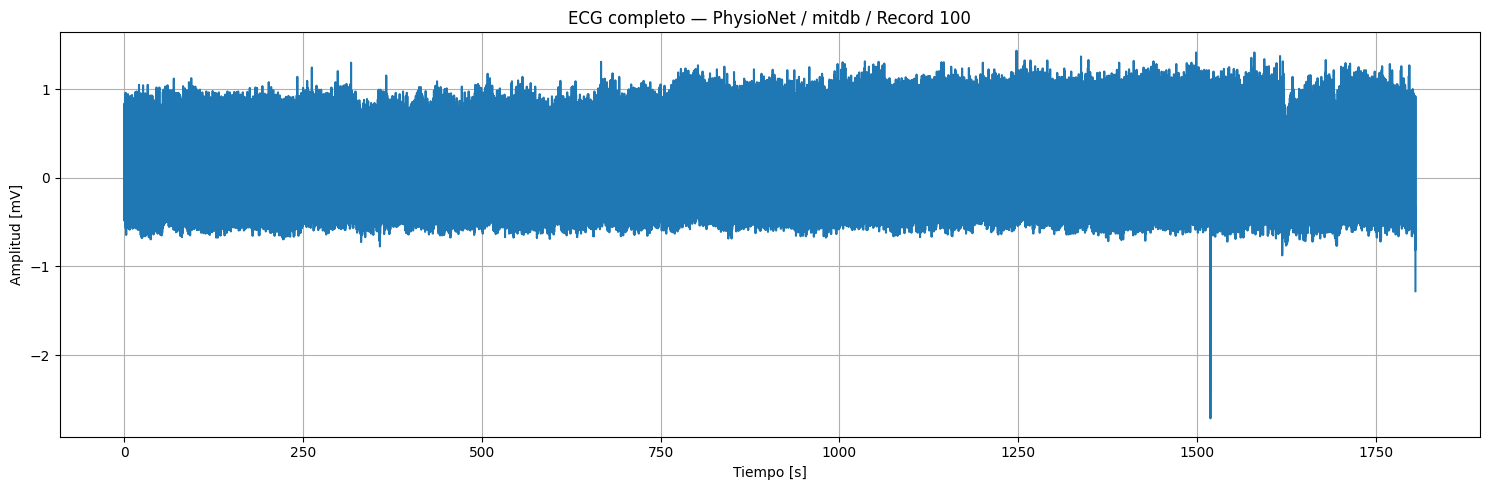

In [ ]:

# ============================================
# GRÁFICA 1: ECG COMPLETO
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 2

1. ¿La señal presenta una amplitud constante?

    - No hay amplitud constante, varía de -0.6 mV a 1 mV.
2. ¿Se pueden identificar visualmente complejos QRS?

    - No se pueden identificar visualmente los complejos QRS debido al largo tiempo abarcado en el eje X.

3. ¿La morfología permanece igual durante todo el registro?

    - No, alrededor de los ~1500 s se observa un pico de amplitud de -2.5 mV que no concuerda con la morfología de un ECG.

4. ¿Se observa ruido?

    - Observando la diferencia de amplitudes a lo largo del eje X, podemos inferir que esto es causado por ruido, ya que deberían estar centradas en 0.
5. ¿Qué ventajas tiene visualizar una señal durante varios minutos?

    - Al visualizar la señal durante varios minutos, podemos ver de manera macro cómo es la amplitud y la morfología de la señal completa. Asimismo, podemos identificar picos extraños como el explicado en la pregunta 3.
6. ¿Qué limitaciones tiene una gráfica demasiado extensa?

    - No nos permite visualizar con claridad el complejo de la señal, en este caso el complejo QRS.


# 10. GRÁFICA 2 — Segmento ECG ampliado

Una señal completa puede dificultar el análisis de eventos individuales.

Por ello seleccionaremos solamente los primeros `DURATION` segundos.


In [ ]:

# ============================================
# SELECCIONAR SEGMENTO
# ============================================

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")


Duración solicitada : 10 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 3600


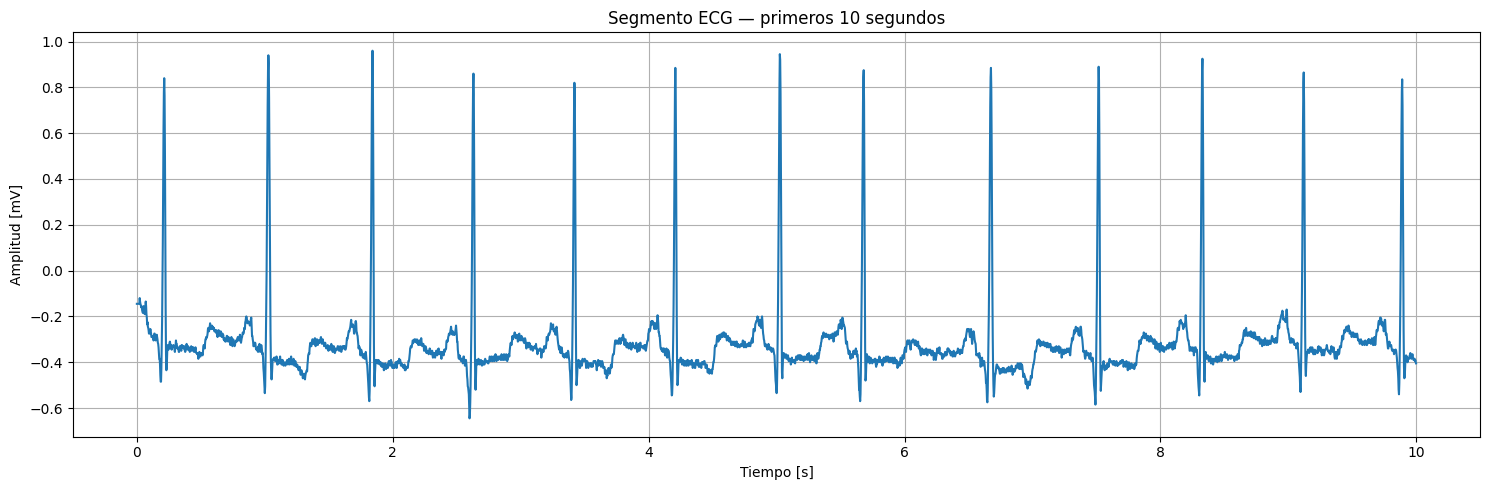

In [ ]:

# ============================================
# GRÁFICA 2: SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Actividad

Observe cuidadosamente la gráfica.

Intente identificar:

- onda P;
- complejo QRS;
- onda T;
- intervalo entre complejos QRS;
- posibles artefactos.

> **Nota:** la identificación automática de ondas no forma parte de este laboratorio. Aquí el objetivo es desarrollar una primera capacidad de observación de señales biomédicas.



# 11. GRÁFICA 3 — Histograma de amplitudes

El histograma permite observar cómo se distribuyen los valores de amplitud de la señal.

Podemos utilizarlo para introducir conceptos como:

- media;
- dispersión;
- valores extremos;
- distribución de amplitudes.


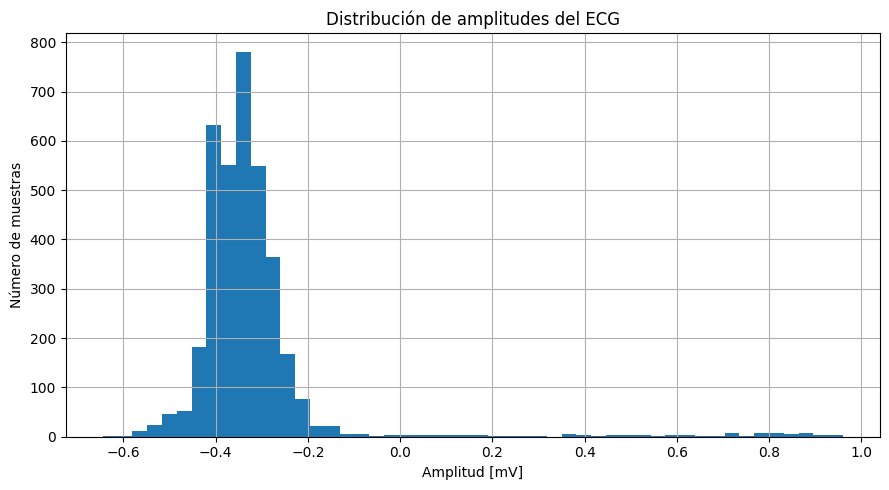

In [ ]:

# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 3

1. ¿Dónde se concentra la mayor cantidad de muestras?

    - La mayor cantidad de muestras se encuentra en el intervalo de [-0.4, -0.2] mV.
2. ¿La distribución parece simétrica?

    - No, la distribución se concentra más hacia el lado izquierdo, en amplitudes negativas.
3. ¿Existen valores extremos?

    - Hay valores extremos en -0.6 mV y en 0.90 mV.
4. ¿Qué podría producir valores de amplitud muy diferentes al valor central?

    - Pueden ser causados por ruido del equipo o por artefactos.
5. ¿El histograma conserva información temporal? Explique.

    - No, el histograma solo muestra la frecuencia de los valores en mV. No indica cuándo ocurre cada uno.


# 12. GRÁFICA 4 — Representación discreta

Una señal digital no solamente puede representarse como una línea continua visualmente.

También podemos observar sus muestras individuales.

Esto permite introducir el concepto:

\[
x[n]
\]

donde `n` representa el índice de muestra.


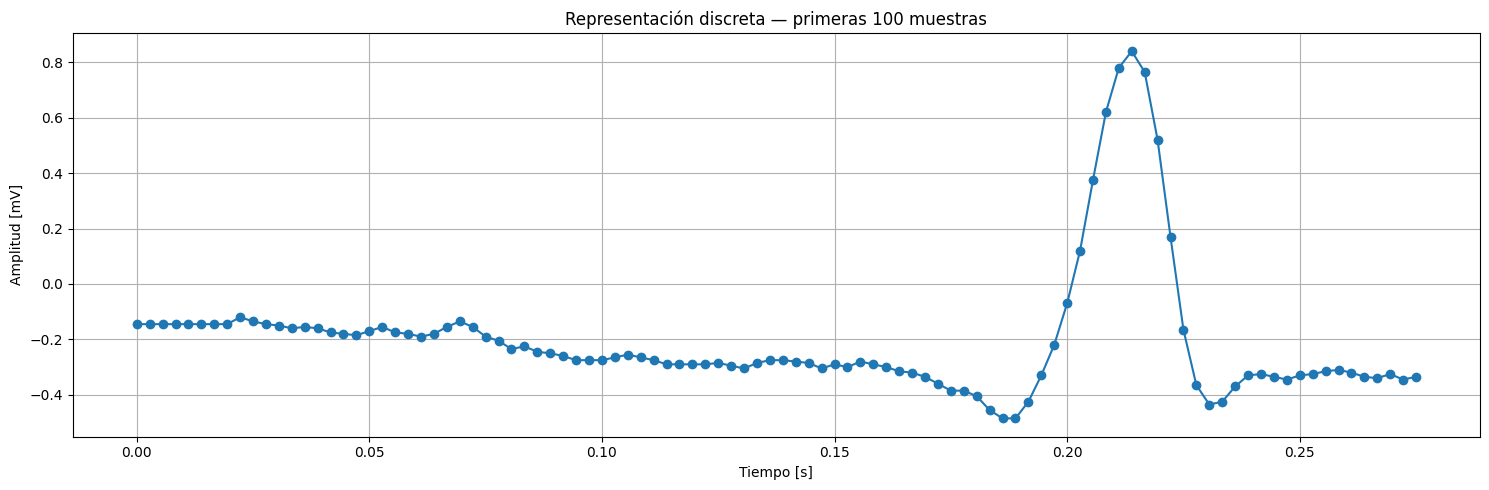

In [ ]:

# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 4

1. ¿Cuántas muestras existen por segundo?

    - De acuerdo con fs=360 Hz, hay 360 muestras por segundo.
2. ¿Qué ocurre si aumentamos `fs`?

    - Si se aumenta fs, aumenta la cantidad de muestras por segundo, lo que significa una mayor resolución de la señal, pero toma más tiempo y memoria.
3. ¿Qué ocurre si disminuimos `fs`?

    - Pasa lo contrario: se pierde resolución y hay peligro de que se incumpla el teorema de Nyquist, es decir, que fs sea menor al doble de la frecuencia máxima de la señal.
4. ¿Qué representa el eje `n` en una señal discreta?

    - El eje "n" representa el índice de muestra en la señal discreta, es decir, la posición entera en la secuencia discreta.
5. ¿Cuál es la relación entre `n`, `fs` y `t`?

    - Se relacionan mediante la ecuación t[n]=n/fs, que expresa el momento en el tiempo en el que la muestra fue capturada.


# 13. Estadística básica de la señal

Antes de exportar la señal calcularemos algunos parámetros básicos.


In [ ]:

# ============================================
# ESTADÍSTICAS BÁSICAS
# ============================================

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")


ESTADÍSTICAS DEL SEGMENTO
Media             : -0.3199
Desviación estándar: 0.1702
Mínimo            : -0.6450
Máximo            : 0.9600
Rango             : 1.6050



# 14. Convertir ECG a archivo WAV

El formato WAV es común en aplicaciones de audio. Sin embargo, nuestra señal es un ECG.

Para poder almacenarla como WAV realizaremos:

```text
ECG original
     ↓
Eliminar componente media
     ↓
Normalizar amplitud
     ↓
Convertir a int16
     ↓
Guardar WAV
```

### ¿Por qué normalizar?

Los valores del ECG están expresados en unidades fisiológicas, mientras que el WAV suele utilizar representaciones enteras, como `int16`.

Utilizaremos el rango:

\[
-32768 \leq x \leq 32767
\]

para `int16`.


In [ ]:

# ============================================
# PREPARAR ECG PARA WAV
# ============================================

ecg_for_wav = signal_segment.astype(float).copy()

# 1. Eliminar componente DC
ecg_for_wav = ecg_for_wav - np.mean(ecg_for_wav)

# 2. Normalizar
max_abs = np.max(np.abs(ecg_for_wav))

if max_abs == 0:
    raise ValueError("La señal no puede normalizarse porque todos sus valores son cero.")

ecg_normalized = ecg_for_wav / max_abs

# 3. Convertir a int16
ecg_int16 = np.int16(
    ecg_normalized * 32767
)

print("Conversión preparada correctamente.")
print(f"Tipo original   : {signal_segment.dtype}")
print(f"Tipo WAV        : {ecg_int16.dtype}")
print(f"Mínimo int16    : {ecg_int16.min()}")
print(f"Máximo int16    : {ecg_int16.max()}")


Conversión preparada correctamente.
Tipo original   : float64
Tipo WAV        : int16
Mínimo int16    : -8322
Máximo int16    : 32767



# 15. Guardar el archivo WAV

La frecuencia de muestreo del WAV será la misma frecuencia de muestreo del registro ECG.

Esto es importante porque permite conservar la separación temporal entre las muestras.


In [ ]:

# ============================================
# GUARDAR WAV
# ============================================

wavfile.write(
    OUTPUT_WAV,
    int(fs),
    ecg_int16
)

print(f"Archivo WAV generado correctamente:")
print(OUTPUT_WAV)


Archivo WAV generado correctamente:
ecg_record_100_channel_0.wav



# 16. Reproducir el archivo WAV

En Google Colab/Jupyter podemos utilizar un reproductor integrado.


In [ ]:

# Reproducir el archivo WAV

display(
    Audio(
       OUTPUT_WAV,
        rate=int(fs)
    )
)




### Preguntas de análisis 5

1. ¿Puede escuchar claramente la señal?

    - Se escuchan los golpes repetitivos causados por el complejo QRS, pero la intensidad es baja, lo que dificulta escucharlos claramente.
2. ¿El sonido corresponde a un sonido fisiológico real?

    - No, porque hemos convertido la señal del ECG a un archivo de audio .wav. Solo obtenemos la sonificación de datos eléctricos, no acústicos.
3. ¿Por qué un ECG puede convertirse a WAV?

    - Porque ambos (ECG y WAV) son series de números que cambian con el tiempo; se puede sonificar cualquier registro matemático.
4. ¿Qué información se conserva al hacer la conversión?

    - Al hacer la conversión, se conserva la información estructural, como la forma de onda (QRS) y su periodicidad, así como la frecuencia de muestreo.
5. ¿Qué información fisiológica podría perderse al escucharla?

    - Se pierde toda la información fisiológica de baja amplitud, como las ondas P y T, alteraciones del segmento ST e incluso cambios morfológicos del complejo QRS.
6. ¿Qué diferencia existe entre representar un ECG gráficamente y reproducirlo como audio?

    - Al representar un ECG gráficamente se visualiza la escala exacta en gráficas de amplitud vs. tiempo, o la frecuencia de valores en el histograma. En la reproducción de audio, solo se percibe el ritmo del complejo QRS.


# 17. Descargar el archivo WAV

En Google Colab se puede descargar el archivo generado.


In [60]:

# ============================================
# DESCARGAR WAV EN GOOGLE COLAB
# ============================================

try:
    from google.colab import files
    files.download(OUTPUT_WAV)
except ImportError:
    print("Este entorno no es Google Colab.")
    print(f"El archivo está disponible localmente como: {OUTPUT_WAV}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# 18. Ejercicios propuestos

## Ejercicio 1 — Cambiar de registro

Modifique:

```python
RECORD = "100"
```

por otro registro válido de la misma base de datos.

Compare:

- frecuencia de muestreo;
- número de canales;
- nombres de canales;
- morfología;
- amplitud;
- distribución.

### Entregable

Incluya una captura o las cuatro gráficas del nuevo registro y escriba una comparación con el registro original.




In [66]:
RECORD_2 = "200"
record_2 = wfdb.rdrecord(
    RECORD_2,
    pn_dir=DATABASE
)
fs_2 = record_2.fs

# Frecuencia de muestreo, número de canales y nombre de canales
print("=" * 55)
print("INFORMACIÓN DEL REGISTRO 1")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)



print("=" * 55)
print("INFORMACIÓN DEL REGISTRO 2 ")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD_2}")
print(f"Frecuencia muestreo : {record_2.fs} Hz")
print(f"Número de muestras  : {record_2.sig_len}")
print(f"Número de canales   : {record_2.n_sig}")
print(f"Canales             : {record_2.sig_name}")
print(f"Unidades            : {record_2.units}")

duration_total_2 = record_2.sig_len / record_2.fs

print(f"Duración total      : {duration_total_2:.2f} segundos")
print("=" * 55)



INFORMACIÓN DEL REGISTRO 1
Base de datos       : mitdb
Registro            : 100
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V5']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos
INFORMACIÓN DEL REGISTRO 2 
Base de datos       : mitdb
Registro            : 200
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V1']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos


  - Comparando los valores del REGISTRO 1 con el REGISTRO 2, se observa que la frecuencia de muestreo, el número de muestras, el número de canales, las unidades y la duración total son los mismos. Lo que cambia son los nombres de los canales: en el REGISTRO 1 son ['MLII', 'V5'] y en el REGISTRO 2 son ['MLII', 'V1'].

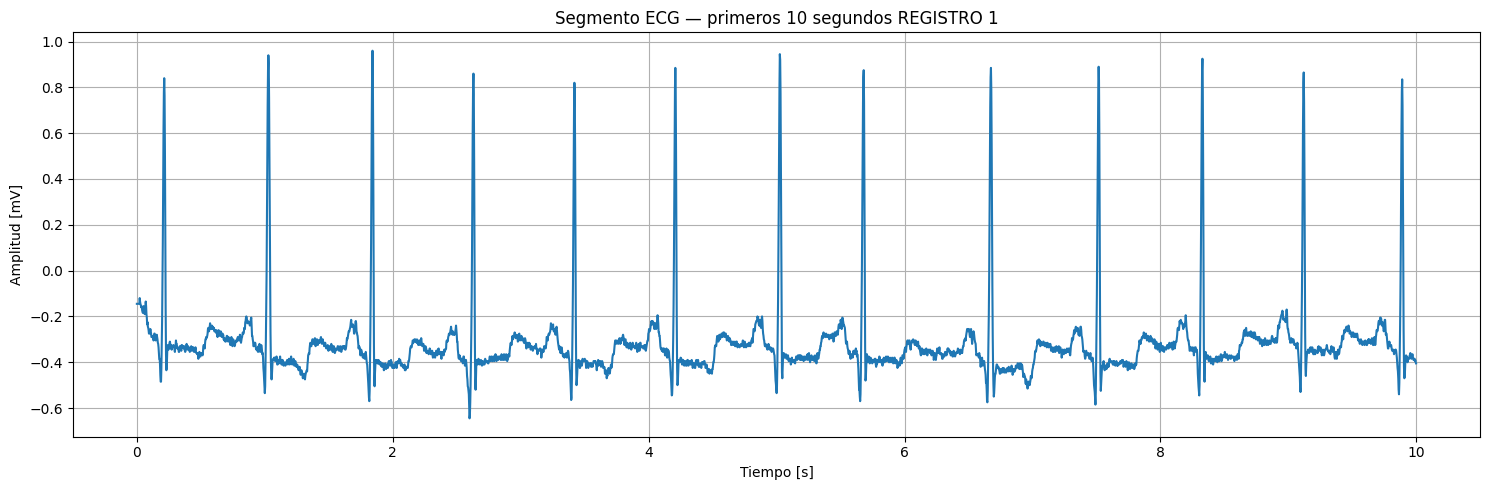

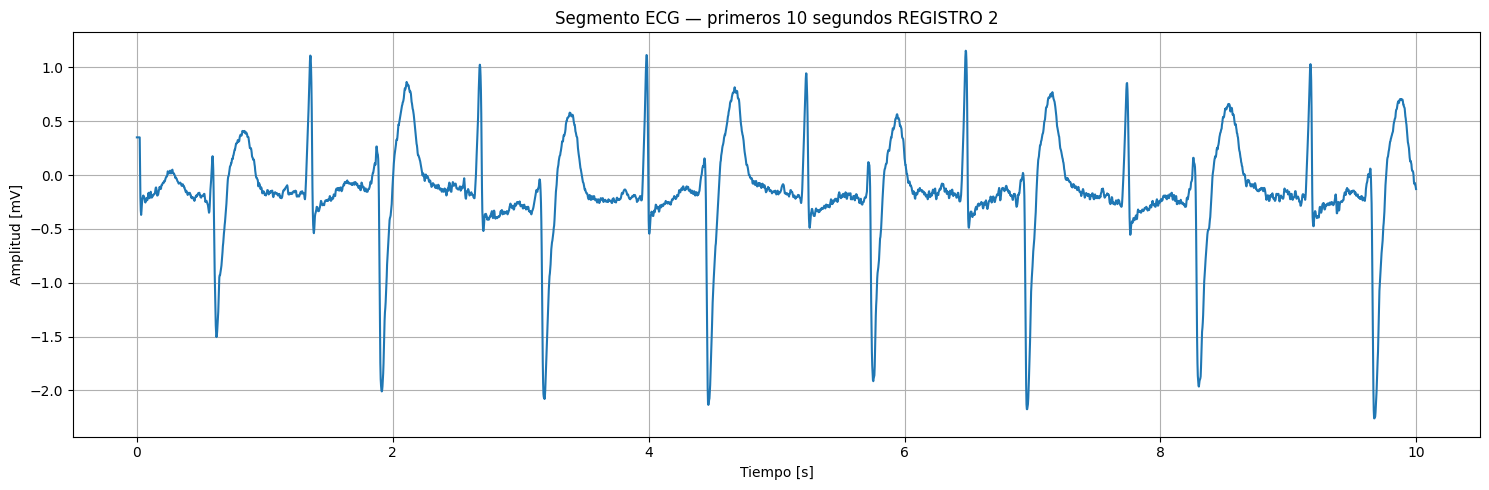

In [67]:
# Morfología y Amplitud
signal_2 = record_2.p_signal[:, CHANNEL]
t_2 = np.arange(len(signal_2)) / fs_2
N_2 = int(DURATION * fs_2)
seg_2 = signal_2[:N_2]
t_2_seg = t_2[:N_2]

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos REGISTRO 1"
)

plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))

plt.plot(t_2_seg, seg_2)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos REGISTRO 2"
)

plt.grid(True)
plt.tight_layout()
plt.show()

 - La morfología del REGISTRO 2 difiere en gran medida de la del REGISTRO 1: se visualizan las ondas P y T con mayor magnitud y ancho, lo que incrementa el intervalo entre cada complejo QRS. Se observa que la amplitud en el REGISTRO 2 es de -2.0 a 1.0 mV, mayor en comparación con el -0.45 a 0.9 mV del REGISTRO 1.

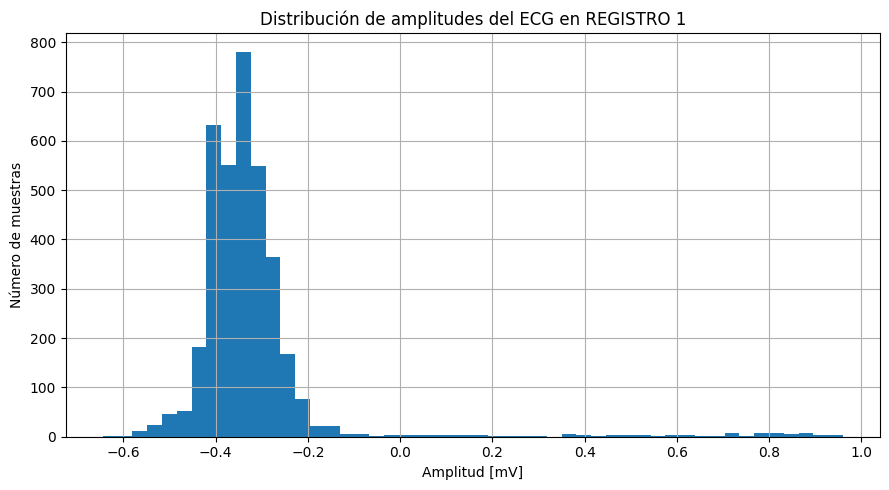

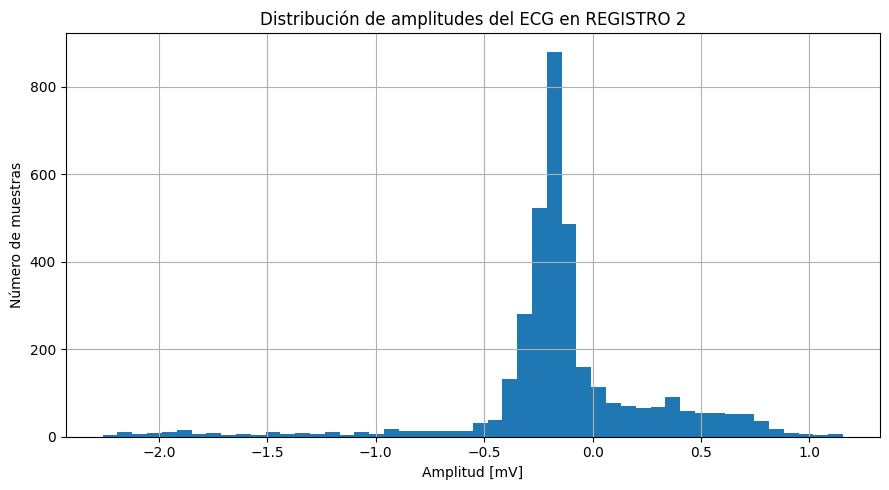

In [69]:
# Distribución
plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG en REGISTRO 1")

plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))

plt.hist(
    seg_2,
    bins=50
)
plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG en REGISTRO 2")

plt.grid(True)
plt.tight_layout()
plt.show()



  - En comparación con la distribución del REGISTRO 1, que se concentra hacia el lado izquierdo con mayor frecuencia en amplitudes negativas, en el REGISTRO 2 se concentra hacia el lado derecho, en el intervalo de -0.5 a 0 mV.

---
## Ejercicio 2 — Cambiar de canal

Modifique:

```python
CHANNEL = 0
```

por otro canal disponible.

Responda:

1. ¿Qué nombre tiene el nuevo canal?
2. ¿Tiene las mismas unidades?
3. ¿La morfología es igual?
4. ¿Qué diferencias observa?



In [70]:
CHANNEL_2 = 1

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO 2 ")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD_2}")
print(f"Frecuencia muestreo : {record_2.fs} Hz")
print(f"Número de muestras  : {record_2.sig_len}")
print(f"Número de canales   : {record_2.n_sig}")
print(f"Canales             : {record_2.sig_name}")
print(f"Unidades            : {record_2.units}")





INFORMACIÓN DEL REGISTRO 2 
Base de datos       : mitdb
Registro            : 200
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V1']
Unidades            : ['mV', 'mV']


 - El nombre del nuevo canal es 'V1', tiene las mismas unidades de mV.

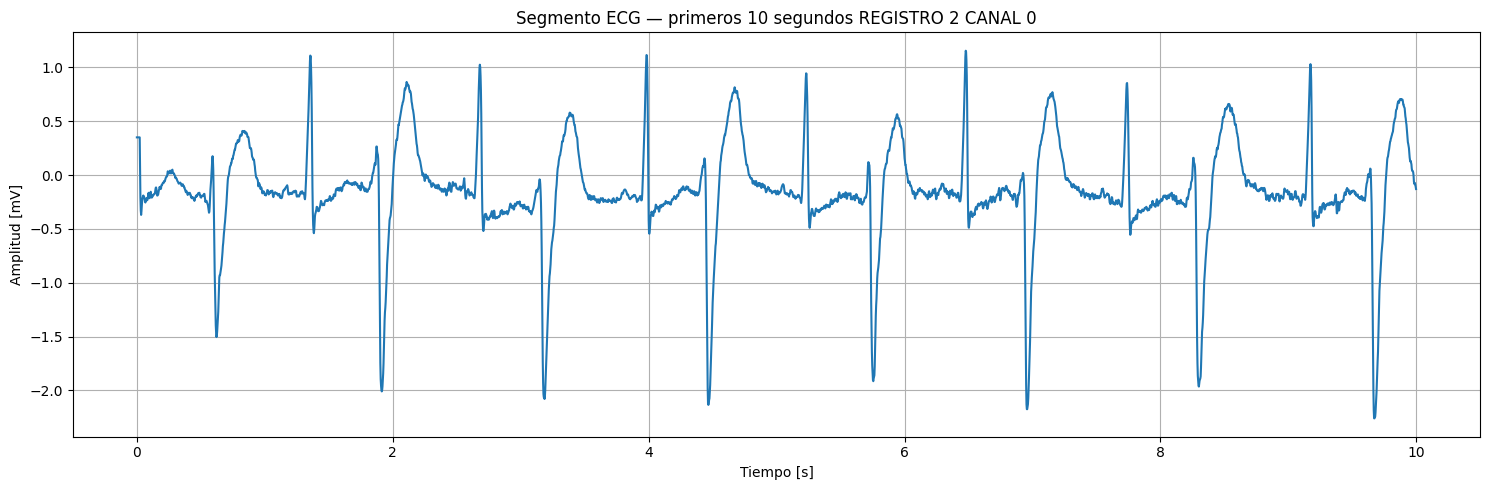

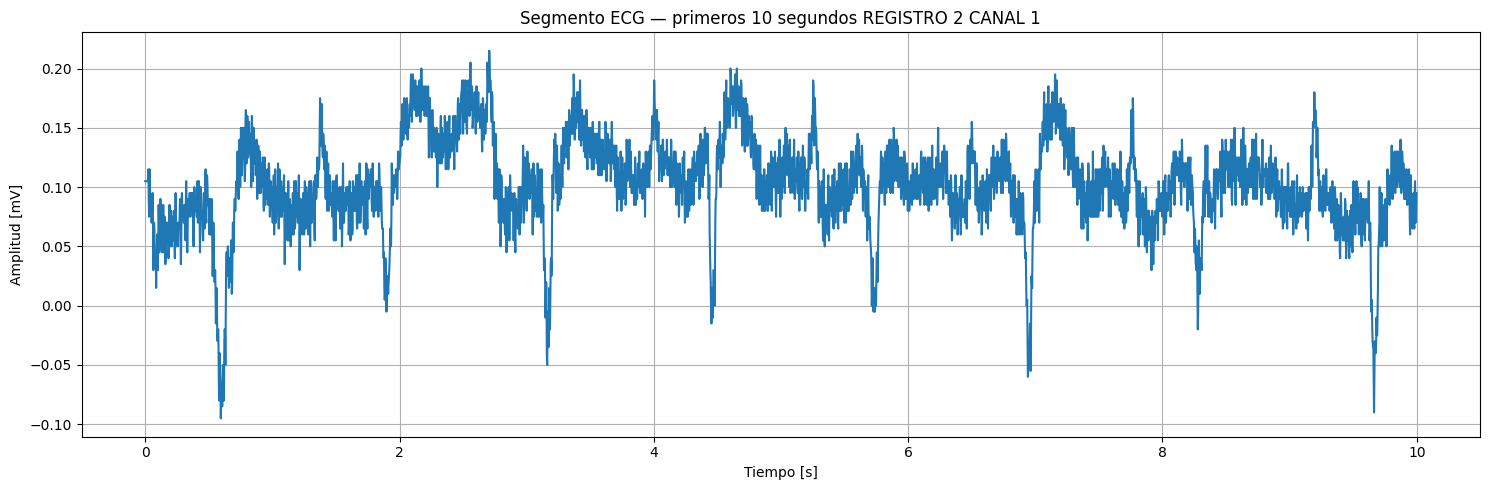

In [72]:
signal_3 = record_2.p_signal[:, CHANNEL_2]
t_3 = np.arange(len(signal_3)) / fs_2
N_3 = int(DURATION * fs_2)
seg_3 = signal_3[:N_3]
t_3_seg = t_3[:N_3]





plt.figure(figsize=(15, 5))

plt.plot(t_2_seg, seg_2)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos REGISTRO 2 CANAL 0"
)

plt.grid(True)
plt.tight_layout()
plt.show()

##############################################################
plt.figure(figsize=(15, 5))

plt.plot(t_3_seg, seg_3)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos REGISTRO 2 CANAL 1"
)

plt.grid(True)
plt.tight_layout()
plt.show()

  - Tiene una morfología similar a la del canal 0, en el sentido de que en el mismo tiempo se presentan los picos característicos. No obstante, en el canal 1 se presenta mayor ruido que distorsiona la morfología, lo que hace que no esté centrado en 0. Asimismo, su rango de amplitud disminuyó a -0.1 a 0.2 mV.

---

## Ejercicio 3 — Cambiar la duración

Pruebe:

```python
DURATION = 5
```

```python
DURATION = 20
```

y compare las visualizaciones.

Explique por qué una duración demasiado pequeña o demasiado grande puede dificultar el análisis.

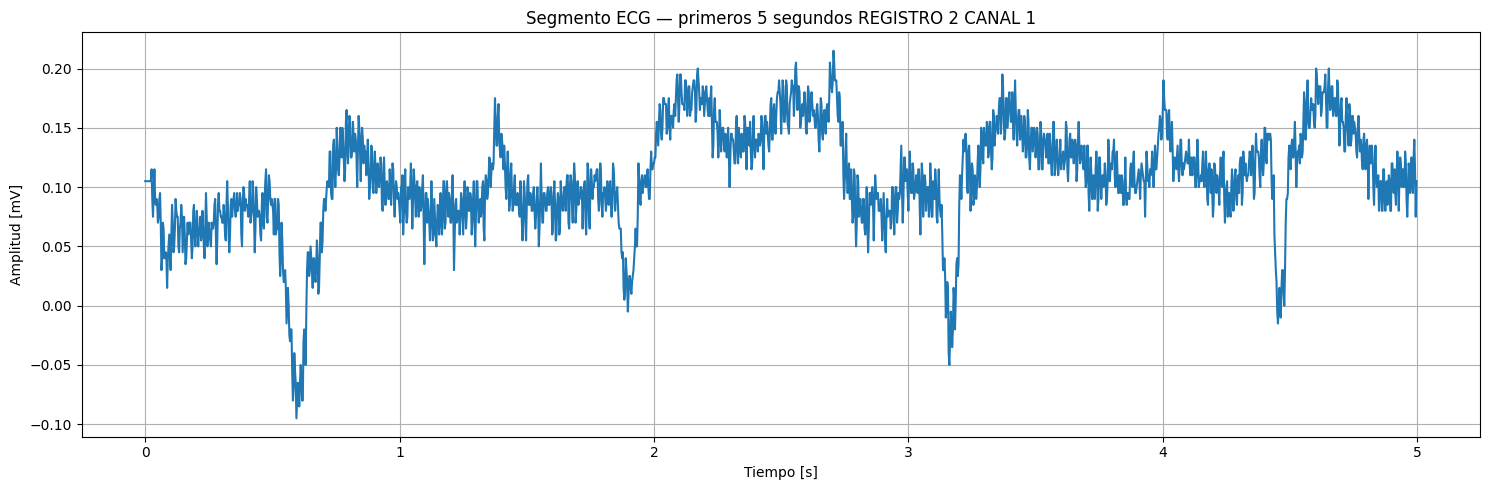

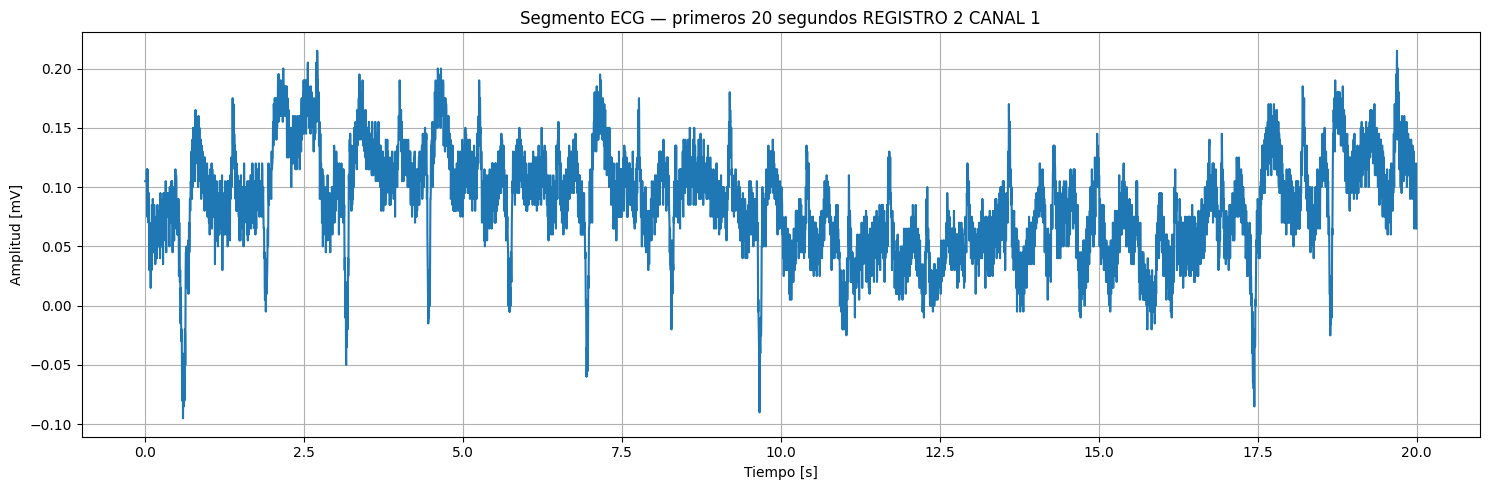

In [73]:
DURATION_A = 5  # segundos
DURATION_B = 20  # segundos


signal_3 = record_2.p_signal[:, CHANNEL_2]
t_3 = np.arange(len(signal_3)) / fs_2

N_A = int(DURATION_A * fs_2)
seg_A = signal_3[:N_A]
t_A = t_3[:N_A]

N_B = int(DURATION_B * fs_2)
seg_B = signal_3[:N_B]
t_B = t_3[:N_B]


# Duración 5 s
plt.figure(figsize=(15, 5))

plt.plot(t_A, seg_A)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION_A} segundos REGISTRO 2 CANAL 1"
)

plt.grid(True)
plt.tight_layout()
plt.show()


# Duración 20 s
plt.figure(figsize=(15, 5))

plt.plot(t_B, seg_B)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION_B} segundos REGISTRO 2 CANAL 1"
)

plt.grid(True)
plt.tight_layout()
plt.show()

 - En una duración demasiado pequeña, como en 5 s, se ven menos complejos QRS, lo que es mejor para el detalle pero no nos permite visualizar la variabilidad en el tiempo. Por otro lado, en un tiempo largo ocurre lo contrario: se dificulta la inspección visual fina, pero se aprecia mejor la variabilidad.

## Ejercicio 4 — Frecuencia de muestreo

Suponga que:

\[
f_s = 360\ Hz
\]

### a) Calcule el periodo de muestreo:

\[
T_s = \frac{1}{f_s}
\]

Ts = 1/360 = 2.78 ms

### b) ¿Cuántas muestras existen en 5 segundos?

Si en 1 segundo hay 360 muestras, en 5 segundos hay 1800 muestras.

### c) ¿Cuántas muestras existen en 10 segundos?

Si en 1 segundo hay 360 muestras, en 10 segundos hay 3600 muestras.


### d) Explique qué sucedería si la frecuencia de muestreo fuese reducida significativamente.

Si se reduce mucho, se corre el riesgo de que se pierda resolución y de que quede por debajo del límite de Nyquist, lo que causaría distorsión en la señal.


---




## Ejercicio 5 — Análisis de amplitud

Utilizando el segmento seleccionado:

1. Calcule la media.
2. Calcule la desviación estándar.
3. Determine el máximo.
4. Determine el mínimo.
5. Calcule el rango.

Explique qué información proporciona cada parámetro.

In [74]:
# ============================================
# ESTADÍSTICAS BÁSICAS
# ============================================

mean_value_3 = np.mean(signal_3)
std_value_3 = np.std(signal_3)
min_value_3 = np.min(signal_3)
max_value_3 = np.max(signal_3)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value_3:.4f}")
print(f"Desviación estándar: {std_value_3:.4f}")
print(f"Mínimo            : {min_value_3:.4f}")
print(f"Máximo            : {max_value_3:.4f}")
print(f"Rango             : {max_value_3 - min_value_3:.4f}")


ESTADÍSTICAS DEL SEGMENTO
Media             : 0.0632
Desviación estándar: 0.4947
Mínimo            : -4.8900
Máximo            : 4.9400
Rango             : 9.8300


- Media: Nivel promedio de la señal
- Desviación estándar: Dispersión del ciclo cardiaco con el ruido
- Máximo: Pico de onda R
- Mínimo: Pico de onda S
- Rango: El rango total del complejo QRS


# 19. Preguntas conceptuales

Responda con sus propias palabras.

### 1. ¿Qué es PhysioNet?

 - PhysioNet es una base de datos de señales fisiológicas como el ECG; estas señales se pueden usar en investigaciones con fines tecnológicos en el ámbito biomédico.

### 2. ¿Qué diferencia existe entre `DATABASE` y `RECORD`?

  - `DATABASE` se refiere a de dónde viene, en este caso, de `mitdb`, mientras que `RECORD` es el registro individual dentro del `DATABASE`.

### 3. ¿Qué representa `fs`?

  - `fs` es la frecuencia de muestreo, es decir, las muestras por segundo en Hz.

### 4. ¿Qué representa `CHANNEL`?

  - `CHANNEL` se refiere a la señal específica que se va a utilizar.

### 5. ¿Qué representa `record.p_signal`?

  - Representa la matriz de las muestras de la señal, con las filas y columnas correspondientes a las muestras y a los canales.

### 6. ¿Por qué necesitamos construir un eje temporal?

  - Debido a que `p_signal` está basado en índices, hay que usar `t[n]=n/fs` para interpretar la señal en el tiempo.

### 7. ¿Qué diferencia existe entre una señal continua y una señal discreta?

  - La señal continua es infinita (definida en todo instante), mientras que la discreta está definida solo en instantes muestreados.

### 8. ¿Por qué no debemos interpretar directamente un archivo WAV como si fuera una señal ECG?

 - Debido a que al pasar de ECG a WAV se pierde información fisiológica, como el offset DC o variaciones de menor amplitud. Hay que recordar que el WAV es solo para audio y NO para el análisis clínico.

### 9. ¿Qué ventajas ofrece trabajar con señales biomédicas reales en lugar de señales sintéticas?

 - Las señales biomédicas reales incluyen variables como el ruido, patologías, entre otras. Esto nos prepara mejor para realizar aplicaciones clínicas reales.

### 10. ¿Qué dificultades encontró durante el laboratorio?

 - El uso de los códigos y escuchar el archivo WAV en el propio Google Colab.


# 20. Reto final

Seleccione un registro diferente y realice el siguiente análisis:

```text
PhysioNet
   ↓
Seleccionar RECORD
   ↓
Identificar canales
   ↓
Seleccionar canal ECG
   ↓
Analizar 10 segundos
   ↓
Gráfica ECG
   ↓
Histograma
   ↓
Representación discreta
   ↓
Estadística
   ↓
Exportar WAV
```

### Informe

Presente:

1. Identificación de la base de datos: DATABASE_FINAL = "mitdb"
2. Identificación del registro: RECORD_FINAL = "105"
3. Frecuencia de muestreo: 360 Hz
4. Canal seleccionado: CHANNEL_FINAL  = 1
5. Duración analizada: DURATION_FINAL = 10



In [97]:
# RETO FINAL
# ============================================
# PARÁMETROS DEL LABORATORIO
# ============================================

DATABASE_FINAL = "mitdb"
RECORD_FINAL = "105"

CHANNEL_FINAL  = 1

DURATION_FINAL = 10

OUTPUT_WAV_FINAL = f"ecg_record_{RECORD_FINAL}_channel_{DATABASE_FINAL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE_FINAL}")
print(f"Registro      : {RECORD_FINAL}")
print(f"Canal         : {CHANNEL_FINAL }")
print(f"Duración      : {DURATION_FINAL } s")
print(f"Archivo WAV   : {OUTPUT_WAV_FINAL}")


Parámetros configurados:
Base de datos : mitdb
Registro      : 105
Canal         : 1
Duración      : 10 s
Archivo WAV   : ecg_record_105_channel_mitdb.wav


In [100]:
record_f = wfdb.rdrecord(
    RECORD_FINAL,
    pn_dir=DATABASE_FINAL
)
fs_f = record_f.fs
signal_f = record_f.p_signal[:, CHANNEL_FINAL]


# Frecuencia de muestreo, número de canales y nombre de canales
print("=" * 55)
print("INFORMACIÓN DEL REGISTRO 1")
print("=" * 55)

print(f"Base de datos       : {DATABASE_FINAL}")
print(f"Registro            : {RECORD_FINAL}")
print(f"Frecuencia muestreo : {record_f.fs} Hz")
print(f"Número de muestras  : {record_f.sig_len}")
print(f"Número de canales   : {record_f.n_sig}")
print(f"Canales             : {record_f.sig_name}")
print(f"Unidades            : {record_f.units}")

duration_total_f = record_f.sig_len / record_f.fs

print(f"Duración total      : {duration_total_f:.2f} segundos")
print("=" * 55)

INFORMACIÓN DEL REGISTRO 1
Base de datos       : mitdb
Registro            : 105
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V1']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos


6. Las 4 gráficas.


In [101]:
# ============================================
# EJE TEMPORAL
# ============================================

t_f = np.arange(len(signal_f)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")

Frecuencia de muestreo: 360 Hz
Periodo de muestreo: 0.002778 segundos
Primer instante: 0.000000 segundos
Último instante: 1805.552778 segundos


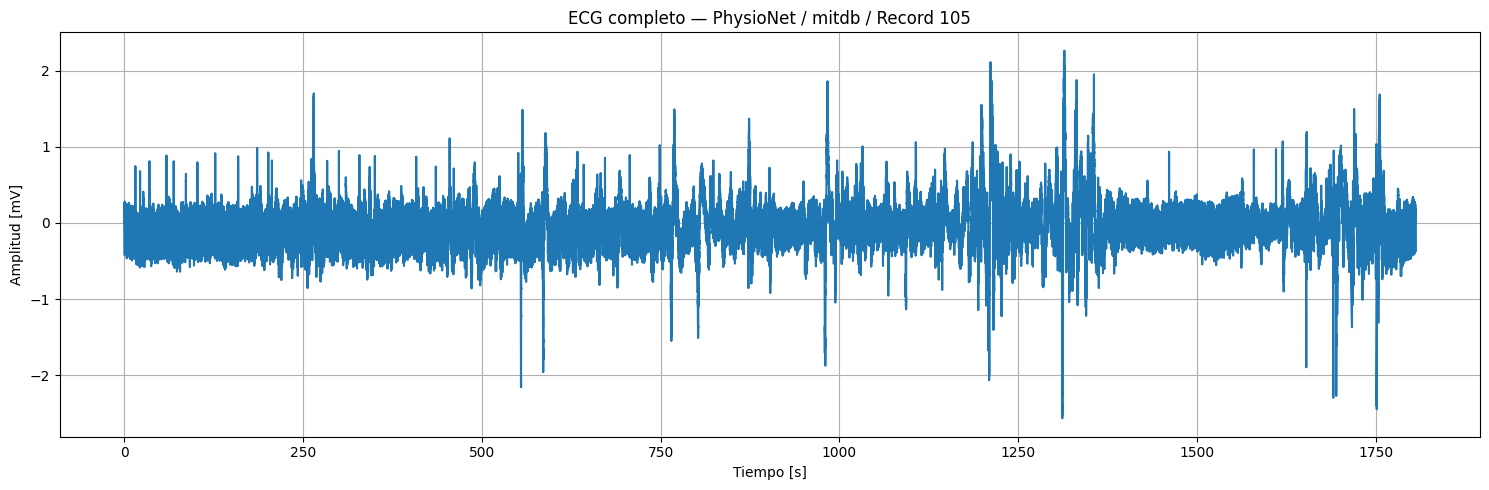

In [103]:
# ============================================
# GRÁFICA 1: ECG COMPLETO
# ============================================
plt.figure(figsize=(15, 5))

plt.plot(t_f, signal_f)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL_FINAL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE_FINAL} / Record {RECORD_FINAL}"
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [104]:
N_f = int(DURATION_FINAL * fs_f)

signal_segment_f = signal_f[:N_f]
t_segment_f = t_f[:N_f]

print(f"Duración solicitada : {DURATION_FINAL} s")
print(f"Frecuencia muestreo : {fs_f} Hz")
print(f"Número de muestras  : {N_f}")

Duración solicitada : 10 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 3600


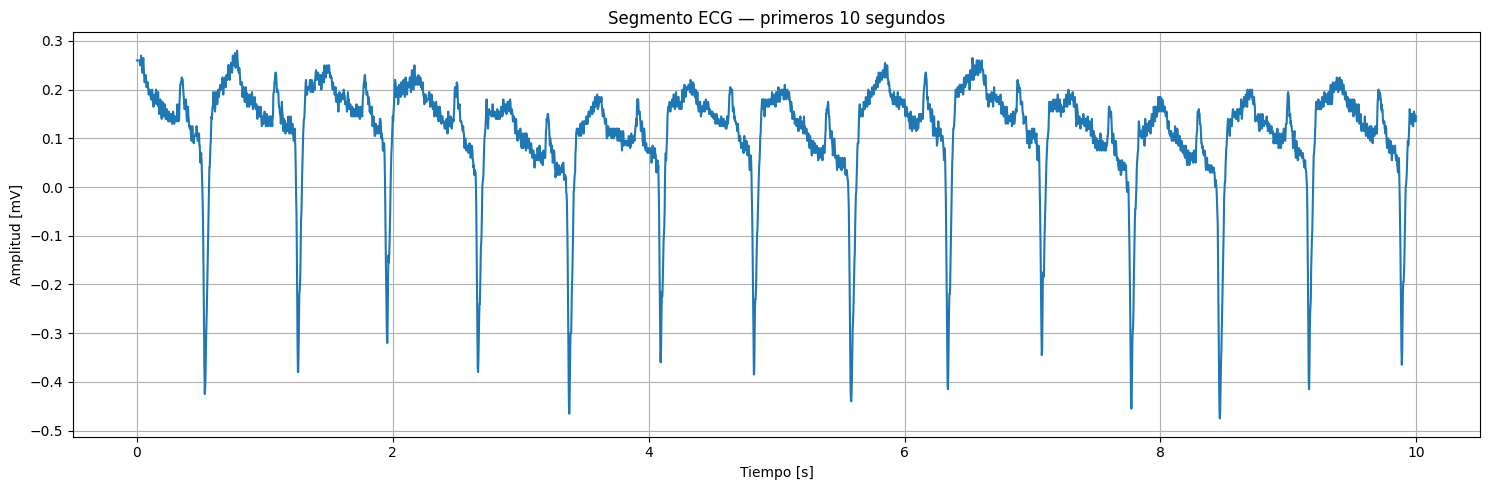

In [105]:
# ============================================
# GRÁFICA 2: SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment_f, signal_segment_f)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL_FINAL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION_FINAL} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()

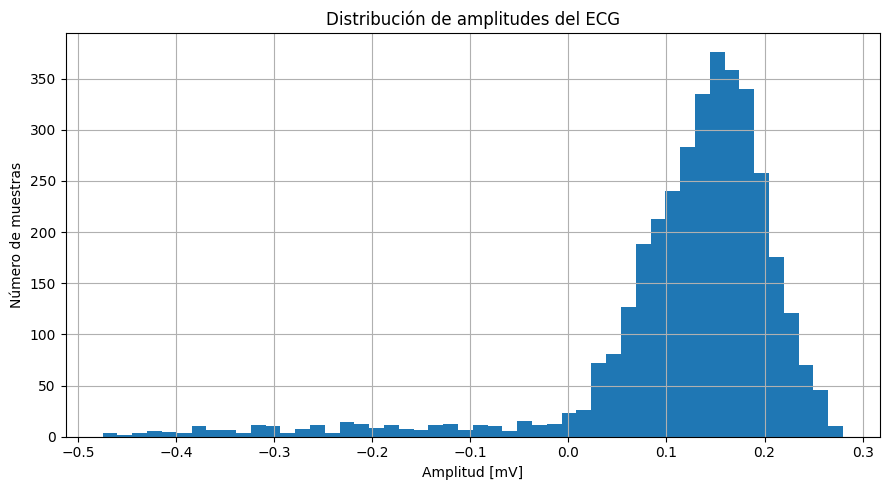

In [106]:
# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment_f,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL_FINAL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()

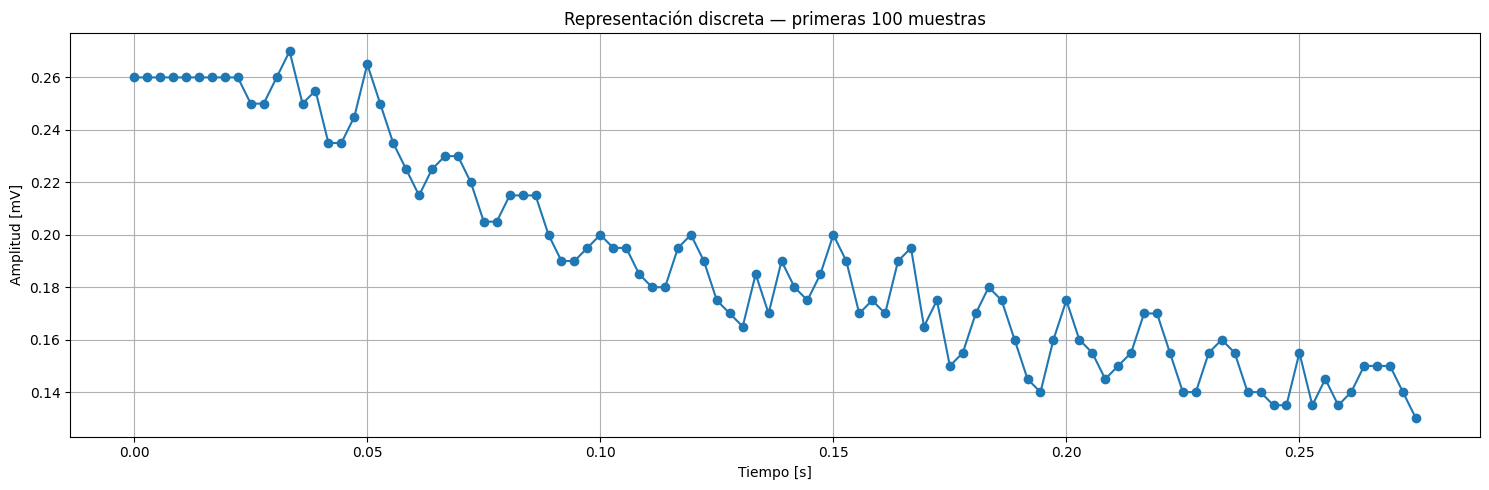

In [107]:
# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES_f = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment_f[:N_SAMPLES_f],
    signal_segment_f[:N_SAMPLES_f],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL_FINAL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES_f} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()

7. Estadísticas.


In [108]:
# ============================================
# ESTADÍSTICAS BÁSICAS
# ============================================

mean_value_f = np.mean(signal_segment_f)
std_value_f = np.std(signal_segment_f)
min_value_f = np.min(signal_segment_f)
max_value_f = np.max(signal_segment_f)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value_f:.4f}")
print(f"Desviación estándar: {std_value_f:.4f}")
print(f"Mínimo            : {min_value_f:.4f}")
print(f"Máximo            : {max_value_f:.4f}")
print(f"Rango             : {max_value_f - min_value_f:.4f}")

ESTADÍSTICAS DEL SEGMENTO
Media             : 0.1169
Desviación estándar: 0.1089
Mínimo            : -0.4750
Máximo            : 0.2800
Rango             : 0.7550


8. Archivo WAV.


In [109]:
# ============================================
# PREPARAR ECG PARA WAV
# ============================================

ecg_for_wav_f = signal_segment_f.astype(float).copy()

# 1. Eliminar componente DC
ecg_for_wav_f = ecg_for_wav_f - np.mean(ecg_for_wav_f)

# 2. Normalizar
max_abs_f = np.max(np.abs(ecg_for_wav_f))

if max_abs_f == 0:
    raise ValueError("La señal no puede normalizarse porque todos sus valores son cero.")

ecg_normalized_f = ecg_for_wav_f / max_abs_f

# 3. Convertir a int16
ecg_int16_f = np.int16(
    ecg_normalized_f * 32767
)

print("Conversión preparada correctamente.")
print(f"Tipo original   : {signal_segment_f.dtype}")
print(f"Tipo WAV        : {ecg_int16_f.dtype}")
print(f"Mínimo int16    : {ecg_int16_f.min()}")
print(f"Máximo int16    : {ecg_int16_f.max()}")

Conversión preparada correctamente.
Tipo original   : float64
Tipo WAV        : int16
Mínimo int16    : -32767
Máximo int16    : 9031


In [110]:
# ============================================
# GUARDAR WAV
# ============================================

wavfile.write(
    OUTPUT_WAV_FINAL,
    int(fs_f),
    ecg_int16_f
)

print(f"Archivo WAV generado correctamente:")
print(OUTPUT_WAV_FINAL)

Archivo WAV generado correctamente:
ecg_record_105_channel_mitdb.wav


In [111]:
# ============================================
# DESCARGAR WAV EN GOOGLE COLAB
# ============================================

try:
    from google.colab import files
    files.download(OUTPUT_WAV_FINAL)
except ImportError:
    print("Este entorno no es Google Colab.")
    print(f"El archivo está disponible localmente como: {OUTPUT_WAV}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

9. Interpretación de los resultados.


In [112]:
# Reproducir el archivo WAV

display(
    Audio(
       OUTPUT_WAV_FINAL,
        rate=int(fs_f)
    )
)

- La señal del "RECORD" 105 presenta una morfología completamente diferente al registro inicial del laboratorio. Presenta un histograma con las frecuencias altas al lado derecho, en amplitudes positivas. Es difícil visualizar el complejo QRS, debido a los valores extremos de las ondas R y T. Por último, presenta un rango menor de 0.7 mV.

- Analizando la información de PhysioNet, se indica lo siguiente:
      - Digoxin, Nitropaste, Pronestyl
      - The PVCs are uniform. The predominant feature of this tape is high-grade noise and artifact.

- Los medicamentos Digoxin (arritmia), Nitropaste (dolor de pecho) y Pronestyl (antiarrítmico) indican que la persona tiene una enfermedad cardiovascular.

- Los PVCs uniformes indican que las contracciones ventriculares prematuras son idénticas, lo que significa que se originan de un solo foco en los ventrículos.

- Esta señal presenta interferencia eléctrica que obstruye la señal cardiaca.

10. Conclusiones.

- Se siguió el flujo del laboratorio para un nuevo registro, 105. De esta manera, se eligieron el canal y la duración de la señal
- A través de las 4 gráficas, se visualizó el comportamiento de la señal en tiempo, frecuencia y forma discreta.
- Por último, se exportó a formato WAV para percibir el complejo QRS de forma auditiva. Esto no reemplaza el análisis clínico de la señal.
- En conclusión, el laboratorio introduce cómo utilizar la base de datos PhysioNet y, con ello, analizar las señales fisiológicas requeridas. Así, se pueden realizar prácticas con un fin clínico en biomédica.


# 21. Conclusiones esperadas

Al finalizar el laboratorio, el estudiante debería comprender que una señal biomédica puede estudiarse desde diferentes perspectivas:

```text
              SEÑAL ECG
                  │
       ┌──────────┼──────────┐
       ↓          ↓          ↓
     Tiempo    Amplitud   Distribución
       │          │          │
       └──────────┼──────────┘
                  ↓
          Señal discreta x[n]
                  ↓
          Procesamiento digital
                  ↓
        Filtros FIR / IIR
                  ↓
         Análisis de señales
```

Este laboratorio constituye la base para los siguientes laboratorios, donde se aplicarán técnicas de **procesamiento digital de señales**, incluyendo filtros FIR, filtros IIR, respuesta en frecuencia y Transformada Z.



# Referencias

- PhysioNet — plataforma de acceso a bases de datos de señales fisiológicas.
- WFDB Python — herramientas Python para lectura y procesamiento de registros fisiológicos.
- MIT-BIH Arrhythmia Database — base de datos utilizada como ejemplo en este laboratorio.

**Nota:** consulte siempre la documentación oficial de la base de datos seleccionada para conocer el significado de sus registros, canales y anotaciones.
